In [203]:
# import the required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,r2_score

In [204]:
#  lord dataset
project_price = pd.read_csv('project_price_prediction.csv')
# data exploration
project_price.head()
project_price.tail()
project_price.sample()
project_price.columns
project_price.describe()

,Estimated_Days,Price
count,3009.000000,3009.000000
mean,32.265537,22152.382519
std,15.962669,6033.068289
min,5.000000,15000.000000
25%,18.000000,16515.000000
50%,32.000000,21555.000000
75%,46.000000,26484.000000
max,60.000000,42897.000000


In [205]:
# data cleaning and filtering
project_price.isnull().sum()
project_price.fillna(project_price.mean(numeric_only=True), inplace=True)
project_price.duplicated().sum()
project_price.drop_duplicates(inplace=True)

In [206]:
# define feature and target
X = project_price.drop(columns=['Price'])
y = project_price['Price']

In [207]:
X = pd.get_dummies(X,columns=['Project_Type','Complexity','UI_Quality','Database','Authentication','API_Integration','Deployment'],drop_first=True)

In [208]:
# train test split of dataset
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
# create and train model 
model = LinearRegression()
model.fit(X_train,y_train)
# make predictions
predictions = model.predict(X_test)
#print('Price predictions',predictions)

In [209]:
# model evaluations
mse = mean_squared_error(y_test,predictions)
print('Mean Squared Error is:',mse)
score = r2_score(y_test,predictions)
print('Project Accuracy score',score)

Mean Squared Error is: 2117967.596921943
Project Accuracy score 0.9387990543825109


In [210]:
# model equations
print('Slope of (m)',model.coef_)
print('Intercept of (b)',model.intercept_)

Slope of (m) [  211.92009405    24.84377001    37.70568997   118.28379238
   120.90314443 -6680.52856394 -3813.54244468  7507.471413
  3783.54158947  2426.6638353   2003.56903714  3439.67311309
  1663.38240626]
Intercept of (b) 11026.963409959393


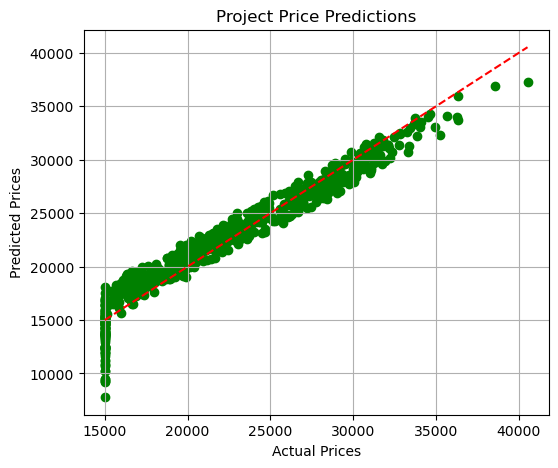

In [213]:
# visualised graph
plt.figure(figsize=(6,5))

plt.scatter(
    y_test,
    predictions,
    color='green'
)

plt.plot(

    [y_test.min(), y_test.max()],

    [y_test.min(), y_test.max()],

    'r--'
)

plt.title(
    'Project Price Predictions'
)

plt.xlabel(
    'Actual Prices'
)

plt.ylabel(
    'Predicted Prices'
)

plt.grid(True)

plt.show()

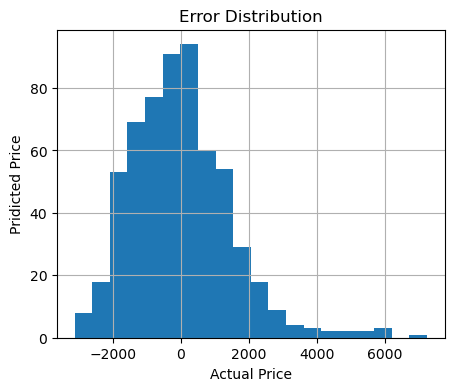

In [224]:
# error distributions
error = y_test - predictions

plt.figure(figsize=(5,4))

plt.hist(
    error,
    bins=20
)

plt.title(
    'Error Distribution'
)
plt.xlabel('Actual Price')
plt.ylabel('Pridicted Price')
plt.grid(True)
plt.show()

In [216]:
# saving training columns
training_columns = X.columns
# new predictions
new_data = pd.DataFrame({

    'Project_Type':['Website'],

    'Complexity':['High'],

    'Estimated_Days':[30],

    'UI_Quality':['Premium'],

    'Database':['Yes'],

    'Authentication':['Yes'],

    'API_Integration':['No'],

    'Deployment':['Yes']
})

# encode
new_data = pd.get_dummies(new_data)

,Estimated_Days,Project_Type_Website,Complexity_High,UI_Quality_Premium,Database_Yes,Authentication_Yes,API_Integration_No,Deployment_Yes
0,30,True,True,True,True,True,True,True


In [218]:
# matching training columns
new_data = new_data.reindex(

    columns=training_columns,

    fill_value=0
)

,Estimated_Days,Project_Type_ML Project,Project_Type_Mobile App,Project_Type_Research Project,Project_Type_Website,Complexity_Low,Complexity_Medium,UI_Quality_CEO-Level,UI_Quality_Premium,Database_Yes,Authentication_Yes,API_Integration_Yes,Deployment_Yes
0,30,0,0,0,True,0,0,0,True,True,True,0,True


In [219]:
# make predictions
new_prediction = model.predict(new_data)

print(
    'Predicted Project Price:',
    new_prediction
)

Predicted Project Price: [27382.62624396]


In [221]:
# save model
joblib.dump(
    model,
    'project_price_model.pkl'
)

['project_price_model.pkl']

In [225]:
# saving training columns
joblib.dump(training_columns,'training_columns.pkl')

['training_columns.pkl']

In [223]:
print('Running Successfully')

Running Successfully
